In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('../data/credit_risk_dataset.csv')

# Ver las primeras filas
print(df.head())

# Ver información básica (tipos de datos y nulos)
df.info()

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [3]:
# 1. ¿Cuántos datos faltan por columna?
print("Datos faltantes:")
print(df.isnull().sum())

# 2. Buscar valores imposibles (Ej: Edad > 100 años o Antigüedad laboral > 60 años)
print("\nResumen estadístico de variables numéricas:")
display(df.describe())

Datos faltantes:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Resumen estadístico de variables numéricas:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
# Eliminamos registros con edades imposibles (mayores a 90 años por ejemplo)
df = df[df['person_age'] <= 90]

# Eliminamos registros donde la antigüedad laboral sea incoherente con la edad
# (Nadie puede trabajar más años de los que tiene de vida)
df = df[df['person_emp_length'] < df['person_age']]

# Para los nulos en tasa de interés, vamos a usar la mediana para no perder filas
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Limpiar nulos en antigüedad laboral con 0 (asumimos que no trabajan)
df['person_emp_length'] = df['person_emp_length'].fillna(0)

print("¡Limpieza completada! Nuevas dimensiones:", df.shape)

¡Limpieza completada! Nuevas dimensiones: (31678, 12)


Correlacion entre el salario de las personas y la posibilidad de no pagar los creditos (Moroso)

Comenzaremos analizando la relacion que hay entre el salario(person_income) y la mora (loan_status) ya que es uno de los factores mas importantes dentro de los negocios.

In [5]:
# Compararemos el sueldo promedio y la mediana según si entraron en mora o no
resumen_ingresos = df.groupby('loan_status')['person_income'].agg(['mean', 'median', 'std'])
print("Resumen de Ingresos por Estado de Préstamo:")
print(resumen_ingresos)

Resumen de Ingresos por Estado de Préstamo:
                     mean   median           std
loan_status                                     
0            71030.439746  60000.0  55437.397537
1            49962.832674  42000.0  37218.388614


Ya que hay una dispersion muy grande en los sueldos utilizaremos una escala logaritmica para visualizar sueldos

C:\Users\Administrador\AppData\Local\Temp\ipykernel_12916\3725808746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2')


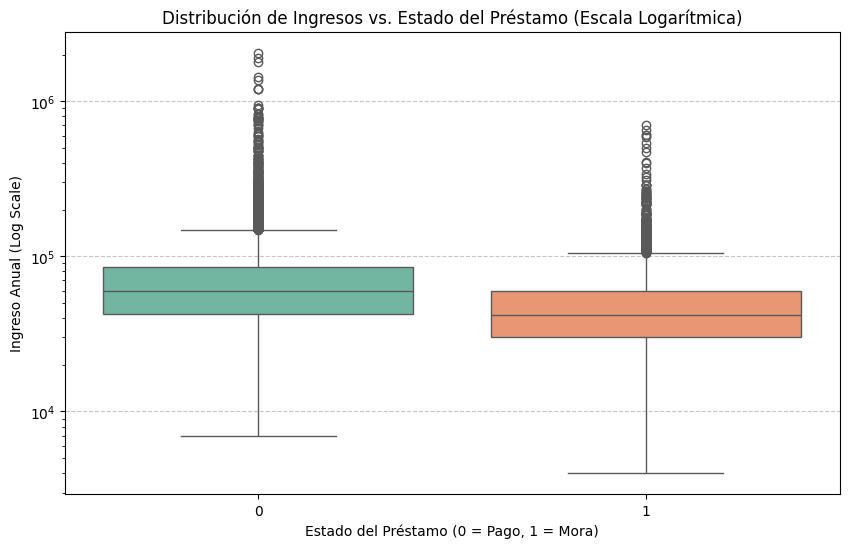

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2')

# Aplicar escala logarítmica al eje Y para ver mejor la distribución
plt.yscale('log')

plt.title('Distribución de Ingresos vs. Estado del Préstamo (Escala Logarítmica)')
plt.xlabel('Estado del Préstamo (0 = Pago, 1 = Mora)')
plt.ylabel('Ingreso Anual (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

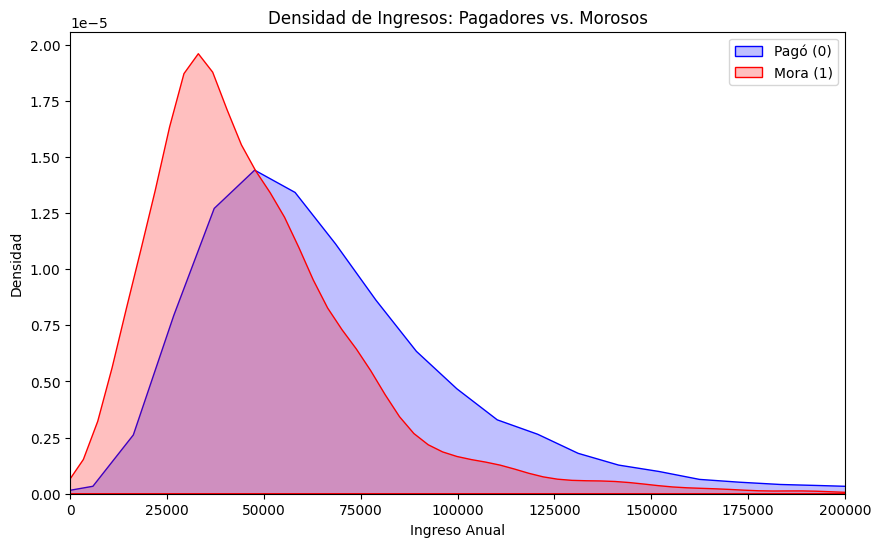

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['loan_status'] == 0]['person_income'], label='Pagó (0)', fill=True, color='blue')
sns.kdeplot(df[df['loan_status'] == 1]['person_income'], label='Mora (1)', fill=True, color='red')

# Limitamos el eje X a 200k para ignorar los sueldos extremadamente altos y ver el detalle
plt.xlim(0, 200000)

plt.title('Densidad de Ingresos: Pagadores vs. Morosos')
plt.xlabel('Ingreso Anual')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [8]:
# Creamos la columna 'dti_ratio' 
# Dividimos el monto del préstamo por el ingreso anual
df['dti_ratio'] = df['loan_amnt'] / df['person_income']

# Verificamos los primeros resultados
print(df[['loan_amnt', 'person_income', 'dti_ratio']].head())

   loan_amnt  person_income  dti_ratio
1       1000           9600   0.104167
2       5500           9600   0.572917
3      35000          65500   0.534351
4      35000          54400   0.643382
5       2500           9900   0.252525


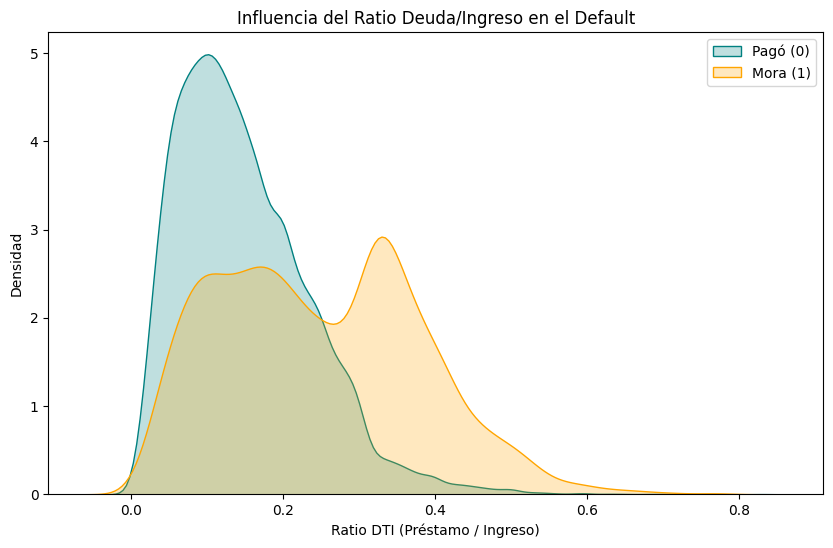

In [9]:
plt.figure(figsize=(10, 6))

# Filtramos: los que pagaron vs los que entraron en mora
sns.kdeplot(df[df['loan_status'] == 0]['dti_ratio'], label='Pagó (0)', fill=True, color='teal')
sns.kdeplot(df[df['loan_status'] == 1]['dti_ratio'], label='Mora (1)', fill=True, color='orange')

plt.title('Influencia del Ratio Deuda/Ingreso en el Default')
plt.xlabel('Ratio DTI (Préstamo / Ingreso)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Seguiremos analizando si los propietarios tienen menos mora que los que alquilan

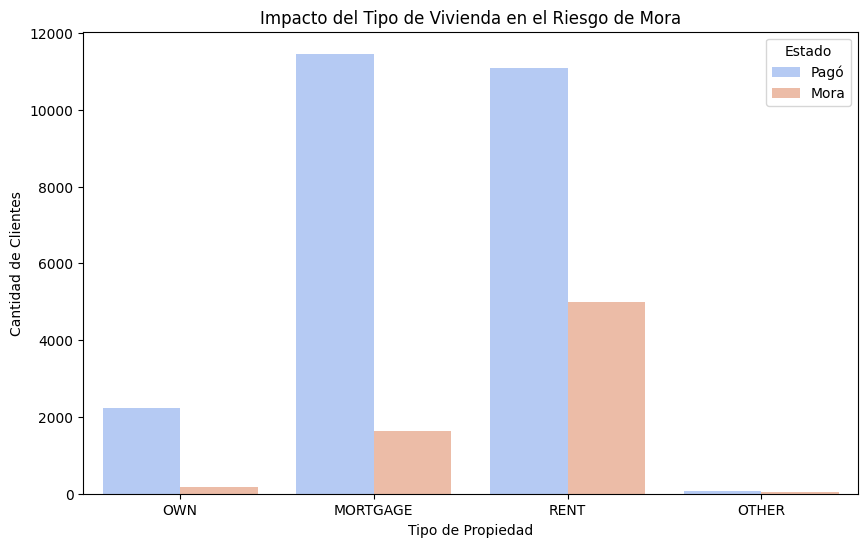

Porcentaje de Mora por Situación Habitacional:
person_home_ownership
RENT        31.080829
OTHER       30.841121
MORTGAGE    12.452254
OWN          6.929461
Name: loan_status, dtype: float64


In [10]:
# Graficar la relación entre el tipo de vivienda y la mora
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_home_ownership', hue='loan_status', palette='coolwarm')

plt.title('Impacto del Tipo de Vivienda en el Riesgo de Mora')
plt.xlabel('Tipo de Propiedad')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Estado', labels=['Pagó', 'Mora'])
plt.show()

# Calcular el porcentaje exacto de mora por categoría
mora_vivienda = df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False) * 100
print("Porcentaje de Mora por Situación Habitacional:")
print(mora_vivienda)

In [11]:
# Seleccionamos las columnas que son texto (categóricas)
columnas_categoricas = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Aplicamos One-Hot Encoding
df_final = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Ver cómo quedó nuestro nuevo dataset "numérico"
print("Nuevas columnas generadas:")
print(df_final.columns)
df_final.head()

Nuevas columnas generadas:
Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'dti_ratio',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='str')


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,dti_ratio,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,0.104167,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0.572917,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,0.534351,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,0.643382,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,0.252525,False,...,False,False,True,False,False,False,False,False,False,False


In [12]:
df_final.to_csv('../data/credit_risk_cleaned.csv', index=False)
print("¡Datos guardados con éxito!")

¡Datos guardados con éxito!
